## 2.2 Tokenizing Text

This essentially just breaks a piece of text apart into "tokens" - or pieces of text seperate from one another. These could be whole words, puncuation, subsets of characters, or even individual characters. Here we are using regular experessions to split the text into tokens, and removing the whitespace.

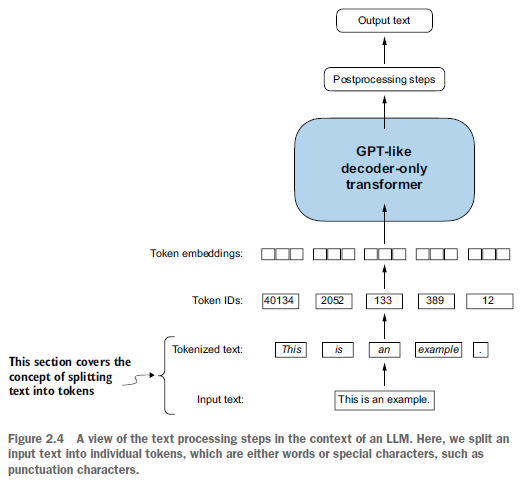

In [1]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

In [2]:
len(raw_text)

20479

In [3]:
import re

text = "Hello, world. This, is a test."
result = re.split(r'(\s)', text)

print(result)

['Hello,', ' ', 'world.', ' ', 'This,', ' ', 'is', ' ', 'a', ' ', 'test.']


In [4]:
preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', raw_text)
preprocessed = [item.strip() for item in preprocessed if item.strip()]
print(len(preprocessed))

4690


In [5]:
print(preprocessed[:30])

['I', 'HAD', 'always', 'thought', 'Jack', 'Gisburn', 'rather', 'a', 'cheap', 'genius', '--', 'though', 'a', 'good', 'fellow', 'enough', '--', 'so', 'it', 'was', 'no', 'great', 'surprise', 'to', 'me', 'to', 'hear', 'that', ',', 'in']


## 2.3 Converting tokens into token IDS

Converting the tokens into numerical representations is the next step. We first create a vocabulary - a sorted set of every token that appears in our token list. We then enumerate this token list so that we have a token --> unique ID mapping for every token.

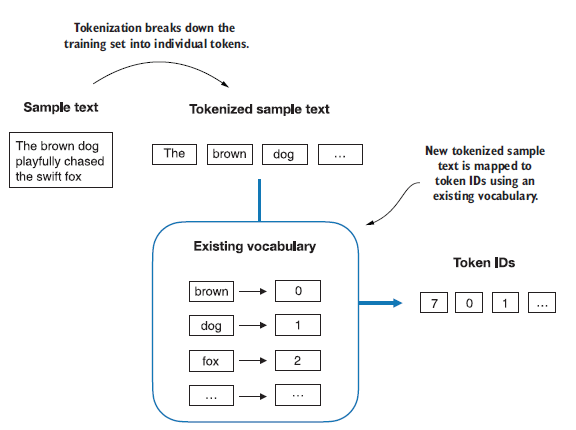

The class that we've written here is a basic example of a tokenizer. It has two variables - the "str_to_int" and the "int_to_str". These are essentially just our vocab but one is going from Token to ID and the other is going from ID to token. It contains two methods - one is the "encode" method which takes a piece of text and returns IDs for each token in the text. The other is the "decode" method which works in the opposite direction - it takes a list of token IDs and returns the tokens themselves.

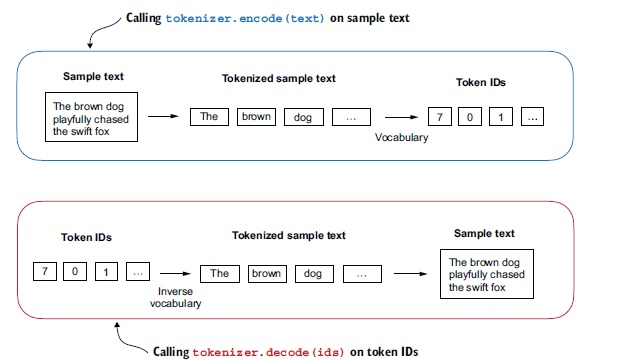

The issue with this is shown in the last cell. If there is a token in the input string, and it's not in our vocabulary there will be a KeyError thrown.

In [6]:
# create sorted "set" of every word - set removes duplicates

all_words = sorted(set(preprocessed))
vocab_size = len(all_words)
print(vocab_size)

1130


In [7]:
# for each word in all_words, assign it an integer and store it in vocab

vocab = {token:integer for integer, token in enumerate(all_words)}
print(len(vocab))

1130


In [8]:
class SimpleTokenizerV1:
    # str_to_int is our Word to ID set
    # int_to_str is our ID to Word set
    def __init__(self, vocab):
        self.str_to_int = vocab
        self.int_to_str = {i:s for s,i in vocab.items()}

    # encode recieves some text, splits it based on previous preprocessing rules
    # then refers to our str_to_int to get the IDs for each word and return the IDs
    def encode(self, text):
        preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', text)

        preprocessed = [
            item.strip() for item in preprocessed if item.strip()
        ]
        ids = [self.str_to_int[s] for s in preprocessed]
        return ids

    # decode recieves a list of ids rather than a list of words
    # then refesrs to our int_to_str to get the words that correspond to each ID
    # joins these back together, adds spaces, and returns the decoded text
    def decode(self, ids):
        text = " ".join([self.int_to_str[i] for i in ids])
        # Replace spaces before the specified punctuatinos
        text = re.sub(r'\s+([,.:;?!"()\'])', r'\1', text)
        return text

In [9]:
# create a tokenizer object using our vocab from "the-verdict.txt"
tokenizer = SimpleTokenizerV1(vocab)

In [10]:
# this is the token representation of the below text
# note this example ONLY contains words that we have captured from "the-verdict.txt" in our vocab

text = """"It's the last he painted, you know,"
Mrs. Gisburn said with pardonable pride."""

ids = tokenizer.encode(text)
print(ids)

[1, 56, 2, 850, 988, 602, 533, 746, 5, 1126, 596, 5, 1, 67, 7, 38, 851, 1108, 754, 793, 7]


In [11]:
# going the opposite direction from ids to text
# note there are some slight differences - our decode method isn't perfect

print(tokenizer.decode(ids))

" It' s the last he painted, you know," Mrs. Gisburn said with pardonable pride.


In [12]:
## this will result in a keyError as the word "Hello" is not in our vocab

text = "Hello, do you like tea?"
#print(tokenizer.encode(text))

## 2.4 Adding special context tokens

The goal of special context tokens is to solve for the problem stated at the end of 2.3. These special context tokens expand beyond just unknown words though - they can also indicate other things like the end of one text/the beginning of another. This way the model knows that it has moved on to a different piece of content.

In the second version of our tokenizer - we add these special context tokens. When the encode method detects a token that does note exist in our vocabulary it assigns in the ID associated with the token "<|unk|>", then when this is passed back to the decoder it will just replace the ID with the actual "<|unk|>" token.

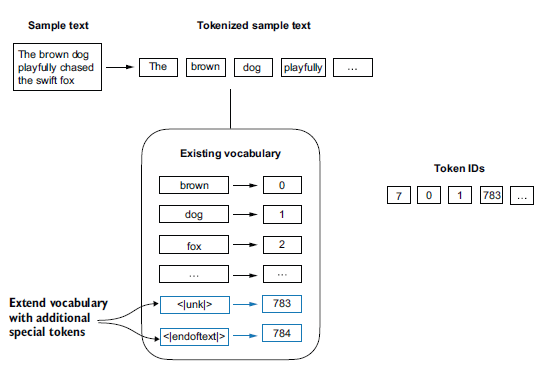

In [13]:
# add special context tokens "endoftext" and "unk" to the token set
# note we have to convert it to a list to get the extend functionality

all_tokens = sorted(list(set(preprocessed)))
all_tokens.extend(["<|endoftext|>", "<|unk|>"])

# same enumeration method from before
vocab = {token:integer for integer, token in enumerate(all_tokens)}

In [14]:
len(vocab.items())

1132

In [15]:
# the new special context tokens are included at the end of our vocab

for i, item in enumerate(list(vocab.items())[-5:]):
    print(item)

('younger', 1127)
('your', 1128)
('yourself', 1129)
('<|endoftext|>', 1130)
('<|unk|>', 1131)


In [16]:
class SimpleTokenizerV2:
    # str_to_int is our Word to ID set
    # int_to_str is our ID to Word set
    def __init__(self, vocab):
        self.str_to_int = vocab
        self.int_to_str = {i:s for s,i in vocab.items()}

    # encode recieves some text, splits it based on previous preprocessing rules
    # then refers to our str_to_int to get the IDs for each word and return the IDs
    def encode(self, text):
        preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', text)

        preprocessed = [
            item.strip() for item in preprocessed if item.strip()
        ]
        # check if the word exists in vocab, if not assign it the unknown token
        preprocessed = [
            item if item in self.str_to_int
            else "<|unk|>" for item in preprocessed
        ]
        ids = [self.str_to_int[s] for s in preprocessed]
        return ids

    # decode recieves a list of ids rather than a list of words
    # then refesrs to our int_to_str to get the words that correspond to each ID
    # joins these back together, adds spaces, and returns the decoded text
    def decode(self, ids):
        text = " ".join([self.int_to_str[i] for i in ids])
        # Replace spaces before the specified punctuatinos
        text = re.sub(r'\s+([,.:;?!"()\'])', r'\1', text)
        return text

In [17]:
tokenizer = SimpleTokenizerV2(vocab)

In [18]:
# now the decoded version of text has the unknown token rather than throwing a keyError
tokenizer.decode(tokenizer.encode(text))

'<|unk|>, do you like tea?'

## 2.5 Byte pair encoding

The previous custom tokenizers were good for gaining an understanding of what a tokenizer does. However, we are going to utilize a package "tiktoken" that utilizies a more advanced encoding method called "Byte Pair Encoding".

When an unknown word is in a token list BPE handles this by breaking the unknown word down into smaller tokens - these could be subwords like "Ak" or "ir" or even just indivudal characters. These then have their own token mappings in the vocabulary and can be combine to reproduce the unknown word. 

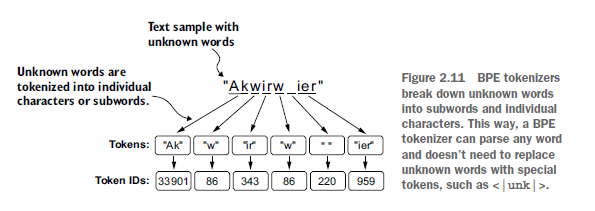

This is largely out of scope for what we're trying to learn here - but BPEs iterate by merging frequent characters into sub-words, and frequent sub-words into words, based on requency thresholds. Again - not neccasary to know for our use case.

In [19]:
from importlib.metadata import version
import tiktoken
print("tiktoken version:", version("tiktoken"))

tiktoken version: 0.13.0


In [20]:
# tiktoken implements BPE (byte pair encoding)
# it work very similarly to our basic example SimpleTokenizer class

tokenizer = tiktoken.get_encoding("gpt2")

In [21]:
# exercise 2.1
# this tokenizer can encode and decode unknown words
# instead of an unknown token - it breaks down unknown words into smaller parts or even individual characters
# this way the output can contain the unknown word after being decoded

integers = tokenizer.encode(text)
print("One word broken into small tokens:", integers)

text = "Akwirw ier"
print("Can still reproduce the original input:", tokenizer.decode(tokenizer.encode(text)))

One word broken into small tokens: [15496, 11, 466, 345, 588, 8887, 30]
Can still reproduce the original input: Akwirw ier


In [22]:
text = (
    "Hello, do you like tea? <|endoftext|> In the sunlit terraces"
    "of someunknownPlace."
)

# this results in an error as we need to specify the special tokens allowed
# tokenizer.encode(text)

print(tokenizer.encode(text, allowed_special={"<|endoftext|>"}))

[15496, 11, 466, 345, 588, 8887, 30, 220, 50256, 554, 262, 4252, 18250, 8812, 2114, 1659, 617, 34680, 27271, 13]


## 2.6 Data sampling with a sliding window

This one is a little confusing. Essentially we use a sliding window so that the model is always predicting the next token. We might give it an input of [The, cat, sat, on] and a target of [cat, sat, on, the]. It might appear at first that the model could "cheat" as it's already seeing the next words in the target - however this is where "casual masking" comes in. Casual masking blocks the model from seeing the earlier positions. So in our example inputs at position 0 the model is predicting "cat", and position 1 it's predicting "sat", in position 2 its predicting "on" and in position 4 it's predicting "the".

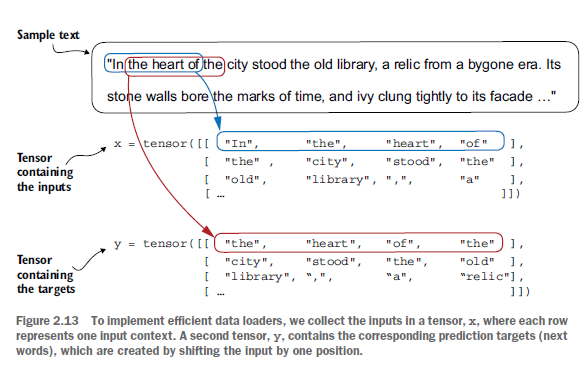

The length and stride can be shifted in the data loader. Say if we wanted a size of 2 instead - then it would only recieve two tokens at a time, if we shifted the stride to 2 then it would move over two spots every time. The batch size is how many token vectors will be passed at a time.

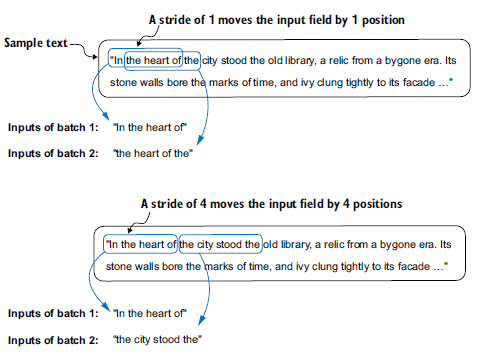

Note these are the inputs - for our use case - the target will always be the inputs shifted over by one position.

In [47]:
# read in "the-verdict.txt" and encode it with the tiktoken tokenizer

with open("the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

enc_text = tokenizer.encode(raw_text)
print(len(enc_text))

5145


In [24]:
enc_sample = enc_text[50:]

In [25]:
context_size = 4

# first four inputs as specified by the context size
x = enc_sample[:context_size]

# the targets are inputs shifted by one position
y = enc_sample[1:context_size+1]

print(f"x: {x}")
print(f"y:      {y}")

x: [290, 4920, 2241, 287]
y:      [4920, 2241, 287, 257]


In [26]:
# context here is the data the LLM has
# desired is the next value that it will predict

for i in range(1, context_size+1):
    context = enc_sample[:i]
    desired = enc_sample[i]
    #print(context, "---->", desired)
    print(tokenizer.decode(context), "---->", tokenizer.decode([desired]))

 and ---->  established
 and established ---->  himself
 and established himself ---->  in
 and established himself in ---->  a


In [27]:
# pytorch implements an efficient dataloader
# there is no need to reinvent the wheel here and do it ourselves
import torch

In [28]:
torch.__version__

'2.5.1+cpu'

In [29]:
from torch.utils.data import Dataset, DataLoader

class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []
    
        # tokenize the entire text
        token_ids = tokenizer.encode(txt)
    
        # use a sliding window to chunk the book into overlapping sequences of max_length
        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i + max_length]
            target_chunk = token_ids[i + 1: i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]

In [30]:
def create_dataloader_v1(txt, batch_size=2, max_length=256,
                        stride=128, shuffle=True, drop_last=True,
                        num_workers=0):

    # Initialize the tokenizer
    tokenizer = tiktoken.get_encoding("gpt2")

    # Create dataset
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

    # Create dataloader
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers
    )
    
    return dataloader

In [31]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

In [32]:
dataloader = create_dataloader_v1(
    raw_text, batch_size=1, max_length=4, stride=4, shuffle=False
)

data_iter = iter(dataloader)
first_batch = next(data_iter)
print(first_batch)

[tensor([[  40,  367, 2885, 1464]]), tensor([[ 367, 2885, 1464, 1807]])]


In [33]:
second_batch = next(data_iter)
print(second_batch)

[tensor([[1807, 3619,  402,  271]]), tensor([[ 3619,   402,   271, 10899]])]


In [34]:
dataloader = create_dataloader_v1(raw_text, batch_size=8, max_length=4, stride=4, shuffle=False)

data_iter = iter(dataloader)
inputs, targets = next(data_iter)
print("Inputs:\n", inputs)
print("\nTargets:\n", targets)

Inputs:
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])

Targets:
 tensor([[  367,  2885,  1464,  1807],
        [ 3619,   402,   271, 10899],
        [ 2138,   257,  7026, 15632],
        [  438,  2016,   257,   922],
        [ 5891,  1576,   438,   568],
        [  340,   373,   645,  1049],
        [ 5975,   284,   502,   284],
        [ 3285,   326,    11,   287]])


## 2.7 Creating token embeddings

For each token - embedding weights are created with random values. This initial setup serves as the LLM's starting point for the learning process. It is essentially a lookup operation that correlates a token to a set of embedding vectors - the token will always have the same set of embedding vectors (as long as it's identical). In our example we start small, but oftentimes these embedding vectors contain many many dimensions.

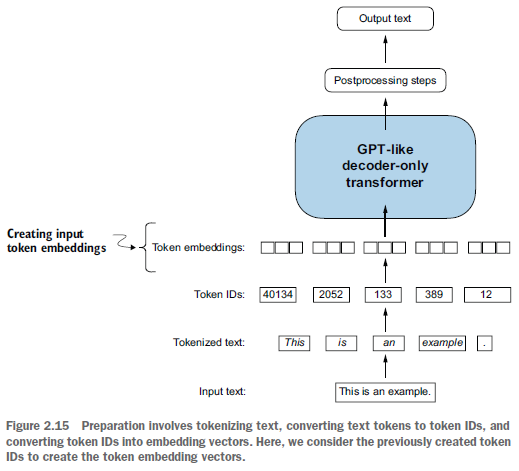

This essentially serves as the LLMs way to relate words to one another using numbers. It doesn't have an understanding that cat and dog are both animals directly - but they will have some kind of mathematical relationship in the embedding vectors that indicates they are similar in context.

In [35]:
input_ids = torch.tensor([ 2,   3,    5,   1])

In [36]:
vocab_size = 6
output_dim = 3

torch.manual_seed(123)
embedding_layer = torch.nn.Embedding(tokenizer.n_vocab, output_dim)

In [37]:
# for each input a 3 dimension random weight is provided
# input in this case is the length of the vocab - three random values for each vocab value
# right now they are random - later during optimization they will be trained and adjusted
print(embedding_layer.weight)

Parameter containing:
tensor([[ 0.3374, -0.1778, -0.3035],
        [-0.5880,  0.3486,  0.6603],
        [-0.2196, -0.3792,  0.7671],
        ...,
        [-0.5931,  1.0895, -0.6854],
        [ 0.7447,  0.5803, -0.4246],
        [-0.3130,  0.7558, -1.2656]], requires_grad=True)


In [38]:
embedding_layer(torch.tensor([3]))

tensor([[-1.1925,  0.6984, -1.4097]], grad_fn=<EmbeddingBackward0>)

In [39]:
embedding_layer(torch.tensor([2]))

tensor([[-0.2196, -0.3792,  0.7671]], grad_fn=<EmbeddingBackward0>)

In [40]:
embedding_layer(input_ids)

tensor([[-0.2196, -0.3792,  0.7671],
        [-1.1925,  0.6984, -1.4097],
        [ 0.2692, -0.0770, -1.0205],
        [-0.5880,  0.3486,  0.6603]], grad_fn=<EmbeddingBackward0>)

## 2.8 Encoding word positions

The LLM doesn't naturally have a notion of the position of tokens within a sequence. The token will always recieve the same token embedding - as stated in the previous section - regardless of where it sits within the sequence of tokens. To solve for this rather than using aboslute position we will put emphasis on the relative distance between two tokens.

We do this with position embeddings. This is a standard set of vectors for each position in a sequence - for example position_embedding(1) is always the same, and it doesn't relate to a specific token. We relate the token embeddings and the token's position by adding together the token embeddings and the position embeddings. For example token_embedding(cat) + position_embedding(1) when the token "cat" is at position 1, or token_embedding(dog) + position_embedding(1) when the token "dog" is at position one. This will result in altering the token embedding based on it's relative position in the sequence of tokens. The model can now distinguish the sequence "cat chased dog" from "dog chased cat".

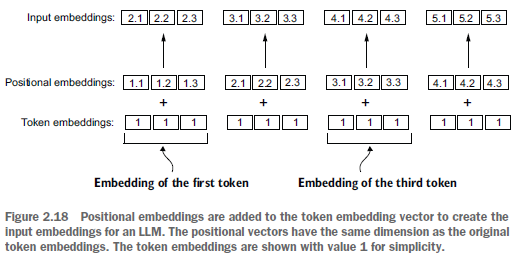

In [41]:
# use the actual sizes for our vocab and tokenizer
# each token has 256 random weights assigned
vocab_size = 50257
output_dim = 256

token_embedding_layer = torch.nn.Embedding(vocab_size, output_dim)

In [42]:
max_length = 4
dataloader = create_dataloader_v1(
    raw_text, batch_size=8, max_length=max_length,
    stride=max_length, shuffle=False
)
data_iter = iter(dataloader)
inputs, targets = next(data_iter)

In [43]:
print("Token IDs:\n", inputs)
print("\nInputs shape:\n", inputs.shape)

Token IDs:
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])

Inputs shape:
 torch.Size([8, 4])


In [44]:
token_embeddings = token_embedding_layer(inputs)

# Batch size of 8, max length (tokens) of 4, 256 weight values
token_embeddings.shape

torch.Size([8, 4, 256])

In [45]:
context_length = max_length
pos_embedding_layer = torch.nn.Embedding(context_length, output_dim)

In [46]:
pos_embeddings = pos_embedding_layer(torch.arange(context_length))
print(pos_embeddings.shape)

torch.Size([4, 256])


# 2 Conclusion

Finally we have taken input text, converted it into tokens, assigned IDs to those tokens, assigned token embeddings (random weights at first), created positional embeddings, then added these together to end with our "Input Embeddings" which will be fed to the transformer.

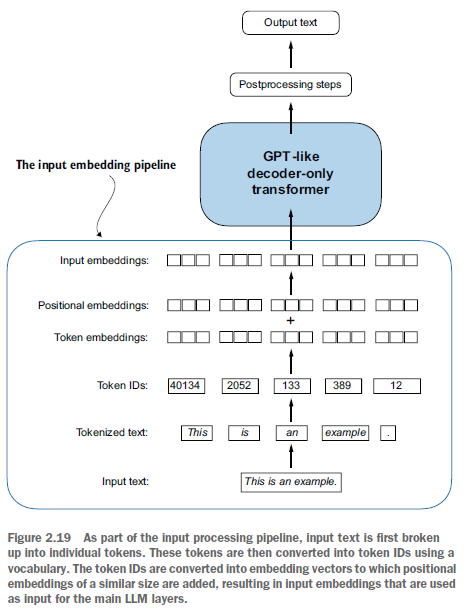